# Recording Na⁺ and K⁺ ionic currents during an AP

Copyright (c) 2025 Open Brain Institute

Authors: Ilkan Kilic

last modified: 08.2025

## Summary
In this example, we simulate a single neuron (me-model) and record its membrane potential (v) together with sodium (Na⁺, ina) and potassium (K⁺, ik) ionic currents. By observing these ion-level currents during an evoked action potential, we can explore how sodium influx and potassium efflux shape the waveform of the spike.

In [ ]:
from entitysdk import Client
from obi_auth import get_token
from pathlib import Path

from obi_notebook import get_projects
from obi_notebook import get_entities
from entitysdk.downloaders.memodel import download_memodel
from entitysdk.models import MEModel
from bluecellulab import tools
from bluecellulab.simulation import Simulation

token = get_token(environment="production", auth_mode="daf")
project_context = get_projects.get_projects(token)

## Load the neuron

In [ ]:
client = Client(environment="production", project_context=project_context, token_manager=token)

# Optional: Download using unique ID
entity_ID = "<MEMODEL-ID>"  # <<< FILL IN UNIQUE MEModel ID HERE

if entity_ID != "<MEMODEL-ID>":
    mmemodel_ids = [entity_ID]
else:
# Alternative: Select from a table of entities
    mmemodel_ids = []
    mmemodel_ids = get_entities.get_entities("memodel", token, mmemodel_ids,
                                            project_context=project_context,
                                            multi_select=False,
                                            default_scale="small")

In [5]:
memodel = client.get_entity(
    entity_type=MEModel,
    entity_id=mmemodel_ids[0],
)
memodel_path=Path(str(memodel.id))
downloaded_memodel = download_memodel(
    client, memodel=memodel, output_dir=memodel_path
)

Please update `venv_path` with path to your python virtual environment.
Next, you will need to compile the mechanisms located in the emodel folder:

In [ ]:
# if you don't have the venv path try the last comment
# try by replacing >> {venv_path}/bin/nrnivmodl << with >> nrnivmodl << in the commands below

venv_path="../../../../.venv/"

# compile mechanisms
!'{venv_path}bin/nrnivmodl' {memodel_path}/mechanisms

# Alternatively
# import os
# os.system(f"{venv_path}/bin/nrnivmodl {emodel_folder_path}/mechanisms")

In [7]:
from bluecellulab.cell.core import Cell
from bluecellulab.circuit.circuit_access import EmodelProperties
from bluecellulab.simulation.neuron_globals import NeuronGlobals

Let's retrieve the memodel data and assign path to files and mechanisms.

In [8]:
hoc_folder = memodel_path / "hoc"
morph_folder = memodel_path / "morphology"
mechanisms_folder = memodel_path / "mechanisms"

Choose a morphology file from the list below. The first file in the folder is selected by default if no choice is made.

In [ ]:
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display

morph_folder = Path(morph_folder)
morph_files = sorted([f.name for f in morph_folder.glob("*") if f.is_file()])

dropdown = widgets.Dropdown(
    options=morph_files,
    value=morph_files[0] if morph_files else None,
    description='Morphology:',
    disabled=False,
)
display(dropdown)
morph_file = morph_folder / dropdown.value

In [10]:
# Look for the only .hoc file in the folder.
# The filename is not fixed, but there must be exactly one file present.
files = [f for f in hoc_folder.iterdir() if f.is_file() and f.suffix == ".hoc"]

if len(files) == 0:
    raise FileNotFoundError(f"No file found in {hoc_folder}")
elif len(files) > 1:
    raise RuntimeError(f"Expected exactly one file in {hoc_folder}, but found {len(files)}: {[f.name for f in files]}")
else:
    hoc_file = files[0]

In [11]:
holding_current = memodel.calibration_result.holding_current
threshold_current = memodel.calibration_result.threshold_current
emodel_properties = EmodelProperties(
    threshold_current=threshold_current,
    holding_current=holding_current,
)

This cell sets global neuronal parameters for the NEURON simulation. The temperature affects ion channel kinetics, and the initial membrane potential should match the model’s resting voltage. Adjust these values based on your HOC model.

In [12]:
neuron_globals = NeuronGlobals.get_instance()
neuron_globals.temperature = 34.0
neuron_globals.v_init = -73.0

We can now create our cell using BlueCelluLab:

In [13]:
from bluecellulab.cell.core import Cell
cell = Cell(hoc_file, morph_file, template_format="v6", emodel_properties=emodel_properties)

In [14]:
print(f"threshold current is {emodel_properties.threshold_current} nA.")
print(f"holding current is {emodel_properties.holding_current} nA.")

threshold current is 0.06611374445370755 nA.
holding current is -0.0125 nA.


Here, we record the total Na⁺ (ina) and K⁺ (ik) currents from the same location, so they can be directly compared during an AP. We use **bluecellulab.cell.section_tools.currents_vars** to inspect available ion-level variables.

In [15]:
from bluecellulab.cell.section_tools import currents_vars

mech_vars = currents_vars(cell.soma)
mech_vars

{'i_pas': {'units': 'mA/cm²', 'kind': 'nonspecific_current'},
 'ica': {'units': 'mA/cm²', 'kind': 'ionic_current'},
 'ihcn_Ih': {'units': 'mA/cm²', 'kind': 'nonspecific_current'},
 'ik': {'units': 'mA/cm²', 'kind': 'ionic_current'},
 'ina': {'units': 'mA/cm²', 'kind': 'ionic_current'}}

Add the recordings

In [16]:
section_obj = tools.get_section(cell, "soma[0]")

cell.add_variable_recording("ina", section_obj, 0.5)  # total sodium current
cell.add_variable_recording("ik", section_obj, 0.5)   # total potassium current
cell.add_variable_recording("v", section_obj, 0.5)    # membrane potential

Inject a simple step current to evoke an AP and simulate

In [17]:
stim_delay = 100  # ms
stim_dur = 1350  # ms
cell.add_step(stim_delay, stim_dur, 0.5, cell.soma, 0.5)

sim = Simulation()
sim.add_cell(cell)
sim.run(2000, dt=0.05, cvode=False)

Retrieve the recorded data

In [18]:
t = cell.get_time()
v_trace = cell.get_variable_recording("v", section_obj, 0.5)
ina_density = cell.get_variable_recording("ina", section_obj, 0.5)  # mA/cm²
ik_density = cell.get_variable_recording("ik", section_obj, 0.5)    # mA/cm²

Retrieve and plot the results

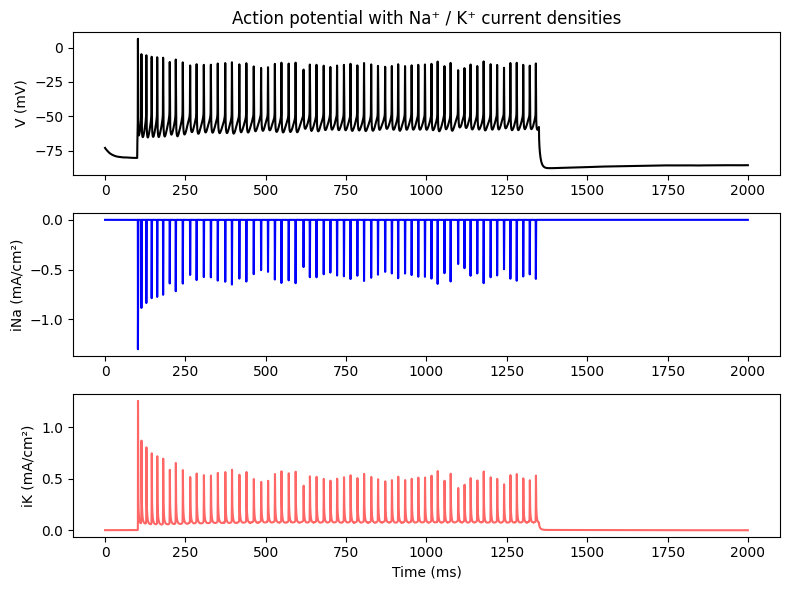

In [19]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Membrane potential
plt.subplot(3, 1, 1)
plt.plot(t, v_trace, color="black")
plt.ylabel("V (mV)")
plt.title("Action potential with Na⁺ / K⁺ current densities")

# Sodium current density
plt.subplot(3, 1, 2)
plt.plot(t, ina_density, color="blue")
plt.ylabel("iNa (mA/cm²)")

# Potassium current density
plt.subplot(3, 1, 3)
plt.plot(t, ik_density, color="red", alpha=0.6)
plt.ylabel("iK (mA/cm²)")
plt.xlabel("Time (ms)")

plt.tight_layout()
plt.show()

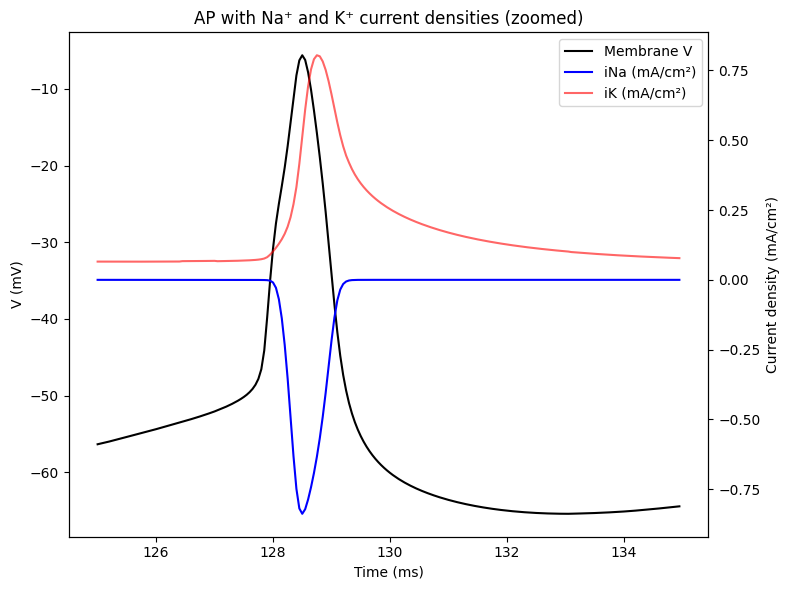

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- Select a small time window around one AP (adjust as needed) ---
t_zoom_start, t_zoom_end = 125, 135  # ms
mask = (t >= t_zoom_start) & (t <= t_zoom_end)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(8, 6))

# Membrane potential (left y-axis)
ax1.plot(t[mask], v_trace[mask], label="Membrane V", color="black")
ax1.set_ylabel("V (mV)")
ax1.set_xlabel("Time (ms)")

# Na⁺ and K⁺ current densities (right y-axis)
ax2 = ax1.twinx()
ax2.plot(t[mask], ina_density[mask], label="iNa (mA/cm²)", color="blue")
ax2.plot(t[mask], ik_density[mask], label="iK (mA/cm²)", color="red", alpha=0.6)
ax2.set_ylabel("Current density (mA/cm²)")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("AP with Na⁺ and K⁺ current densities (zoomed)")
plt.tight_layout()
plt.show()

The plot shows a zoomed view of one action potential. The membrane potential (black) rises sharply, accompanied by a brief inward Na⁺ current density (blue, small negative deflection) and a delayed outward K⁺ current density (red, positive deflection in mA/cm²) that repolarizes the cell.